<div style="background-color:#000047; padding: 30px; border-radius: 10px; color: white; text-align: center;">
    <img src='Figures/alinco_white_text.png' style="height: 100px; margin-bottom: 10px;"/>
    <h1> Módulo 1: Crear una Red Neuronal Convolucional con Pytorch</h1>
    <h3>Aprendizaje Automático Avanzado 2026</h3>
</div>

Ahora entrenaremos **redes neuronales convolucionales (CNN)** con **PyTorch**, desde una red sencilla hasta técnicas de **transfer learning** con modelos preentrenados.

> Referencias: [Tutorial de CIFAR-10 en PyTorch](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html) y [Tutorial de Transfer Learning](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html).


Las redes convolucionales, a diferencia de las redes densas (MLP) que vimos antes, **asumen que la entrada es una imagen** y añaden un conjunto de capas especializadas en **extraer automáticamente características** (*features*) de esa imagen. Esta extracción automática es lo que les da tanta potencia en dominios como la **visión por computadora**, el texto y la voz.

Ideas clave:

- Las neuronas de una capa convolucional se organizan en **3 dimensiones**: ancho, alto y profundidad (canales). Cada filtro se conecta solo a una **pequeña región** de la imagen de entrada (su *campo receptivo*), en lugar de conectarse a todos los píxeles como en un MLP. Esto reduce drásticamente el número de conexiones.

- Además, los **pesos se comparten**: el mismo filtro se desliza por toda la imagen. Así, una característica (por ejemplo, un borde) se detecta sin importar en qué parte de la imagen aparezca, con muchos menos parámetros.

- Una CNN típica se divide en dos partes: la parte **convolucional** (extractora de características) y la parte **totalmente conectada** (*fully-connected*, para la clasificación final). Para unirlas, se **aplana** (*flatten*) la salida de la última capa convolucional a un vector 1D.


### La operación de convolución

De forma muy simplificada, la **convolución** aplica un **filtro** (o *kernel*) a la imagen en cada posición de sus píxeles y para cada uno de sus canales (por ejemplo, los canales Rojo-Verde-Azul, RGB). El objetivo del entrenamiento es **aprender los pesos** de esos filtros que mejor extraen las características de las imágenes (bordes, texturas, formas...).

**Hiperparámetros de cada capa convolucional:**

- **Número de filtros** $C_{out}$: determina cuántos mapas de características produce la capa (la profundidad de la salida).
- **Tamaño del filtro** $F$ (*filter size* o campo receptivo): el alto y ancho del kernel que se desliza sobre la imagen.
- **Stride** $S$: el desplazamiento del filtro. $S=1$ mueve el filtro de un píxel a la vez; $S=2$, de dos en dos, etc.
- **Padding** $P$: cantidad de píxeles (normalmente ceros) que se añaden alrededor de la imagen para controlar el tamaño de salida.

**Dimensiones de entrada y salida:**

- Entrada: imagen $W_{in} \times H_{in} \times C_{in}$
- Salida: volumen $W_{out} \times H_{out} \times C_{out}$, donde:

$$W_{out} = \frac{W_{in} - F + 2P}{S} + 1 \qquad H_{out} = \frac{H_{in} - F + 2P}{S} + 1$$


> **Importante:** al diseñar una arquitectura, los resultados de estas fórmulas (tanto para convolución como para *pooling*) deben ser siempre **números enteros**. Si una combinación de $F$, $S$ y $P$ produce un valor no entero para $W_{out}$ o $H_{out}$, PyTorch arrojará un error.


### Pooling (submuestreo)

La operación de ***pooling*** reduce (*downsampling*) el ancho y el alto de la imagen, disminuyendo así el número de parámetros y de cálculos posteriores (su razón principal de uso), a la vez que aporta cierta **invarianza a pequeñas traslaciones**.

**Hiperparámetros:**

- **Tamaño del filtro** $F$
- **Stride** $S$
- **Criterio de pooling**: lo más común es ***max pooling*** (tomar el valor máximo de cada región $F \times F$), aunque también existe el *average pooling* (el promedio).

**Dimensiones** (el número de canales $C$ **no cambia**):

- Entrada: imagen $W_{in} \times H_{in} \times C$
- Salida: imagen $W_{out} \times H_{out} \times C$, donde:

$$W_{out} = \frac{W_{in} - F}{S} + 1 \qquad H_{out} = \frac{H_{in} - F}{S} + 1$$


### Función de costo: Cross-Entropy

Para una imagen cuya clase correcta tiene índice $i$, la **entropía cruzada** (*cross-entropy loss*) se define como:

$$L_i = -\log\!\left(\frac{e^{f_i}}{\sum_j e^{f_j}}\right) = -f_i + \log\!\left(\sum_j e^{f_j}\right)$$

donde $\dfrac{e^{f_i}}{\sum_j e^{f_j}}$ es la función **Softmax**, que convierte las salidas lineales (*logits*) de la red en **probabilidades** que suman 1. La pérdida total de un *minibatch* es el promedio de las pérdidas de todas sus imágenes.

Veamos un ejemplo numérico paso a paso:


In [1]:
import numpy as np

f_10_clases = np.array([-0.3377, 
                        -0.7665,  
                         0.5616,  
                         0.8967,  
                         0.1177,  
                         0.2450,  
                         1.9977, 
                        -1.2577, 
                        -0.9191, 
                        -1.2244])

# aplicamos la función e a cada una
f_10_clases_exp = np.exp(f_10_clases)
print(f_10_clases_exp)

[0.71340928 0.46463645 1.75347582 2.4514998  1.12490659 1.27762131
 7.3720808  0.28430718 0.39887787 0.29393401]


In [2]:
# transformamos estas clases en probabilidades...
f_10_clases_prob = f_10_clases_exp / np.sum(f_10_clases_exp)
print(f_10_clases_prob)
print(np.sum(f_10_clases_prob))

[0.0442157  0.02879725 0.10867698 0.15193913 0.0697195  0.07918445
 0.45690706 0.0176208  0.02472167 0.01821745]
1.0


In [3]:
# supongamos que la clase correcta era i=2, la pérdida por entropía cruzada sería:
print(-np.log(f_10_clases_prob[2]))

2.2193752758952074


Minimizar esta función equivale a maximizar la probabilidad de la clase correcta (y, por lo tanto, a minimizar la probabilidad de las demás).

>  Una excelente herramienta interactiva para **visualizar** cómo funciona una CNN por dentro: [CNN Explainer](https://poloclub.github.io/cnn-explainer/).


## Creando un modelo CNN para CIFAR-10

Usaremos el dataset de imágenes [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html): **60 000 imágenes** de $32\times32$ píxeles a color (3 canales RGB), repartidas en **10 clases mutuamente excluyentes** (6 000 imágenes por clase), de las cuales 50 000 son de entrenamiento y 10 000 de prueba.

Las clases son: *avión, automóvil, pájaro, gato, ciervo, perro, rana, caballo, barco* y *camión*. Construiremos una CNN que aprenda a clasificarlas.


![CIFAR10](Figures/cifar10.png)

Fuente: Alex Krizhevsky en https://www.cs.toronto.edu/~kriz/cifar.html

> **Nota sobre el hardware:** el código funciona tanto en **CPU** como en **GPU**. Si dispones de una GPU NVIDIA con CUDA, PyTorch la usará automáticamente (lo detectamos con `torch.cuda.is_available()`). En CPU el entrenamiento es más lento, por lo que usaremos pocas épocas. También puedes ejecutarlo en **Google Colab** activando la GPU en *Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU*.


In [4]:
import os

# Evita el conflicto de múltiples runtimes OpenMP (MKL + libgomp) en Windows
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
%matplotlib inline

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("PyTorch:", torch.__version__, "| Dispositivo:", device)

PyTorch: 2.13.0+cpu | Dispositivo: cpu


Con las [transformaciones de torchvision](https://pytorch.org/vision/stable/transforms.html) aplicamos una serie de operaciones a **todas** las imágenes del dataset. Aquí:

1. `ToTensor()` convierte cada imagen (PIL) a un tensor con valores en $[0, 1]$.
2. `Normalize((0.5,...), (0.5,...))` estandariza cada canal restando la media (0.5) y dividiendo por la desviación (0.5), de modo que los valores pasen del rango $[0, 1]$ al rango $[-1, 1]$.

Trabajar con valores centrados en cero (rango $[-1, 1]$) suele facilitar y estabilizar el entrenamiento de las redes neuronales.


In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

BATCH_SIZE = 64

# CIFAR-10 de entrenamiento (se descarga la primera vez)
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

# CIFAR-10 de prueba
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

classes = ('avión', 'automóvil', 'pájaro', 'gato', 'ciervo',
           'perro', 'rana', 'caballo', 'barco', 'camión')
print("Entrenamiento:", len(trainset), "| Prueba:", len(testset))

100%|██████████| 170M/170M [02:38<00:00, 1.08MB/s] 


Entrenamiento: 50000 | Prueba: 10000


Veamos algunas de las imágenes de entrenamiento

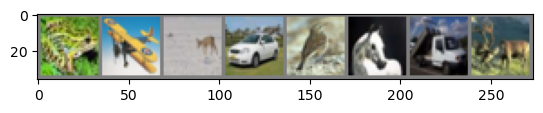

      rana      avión     ciervo  automóvil     pájaro    caballo     camión     ciervo


In [6]:
from utils import imshow

# Obtenemos un lote de imágenes de entrenamiento
dataiter = iter(trainloader)
images, labels = next(dataiter)   # en PyTorch moderno se usa next(dataiter), no dataiter.next()

# Mostramos las primeras 8 imágenes y sus clases
imshow(torchvision.utils.make_grid(images[:8]))
print(' '.join(f'{classes[labels[j]]:>10}' for j in range(8)))

**Definimos ahora nuestra red convolucional. La misma va a tener la siguiente arquitectura:**

* **Entrada:** imagen 32x32x3
* Capa **conv1** con `kernel=5` (es decir 5x5), `stride=1`, `c_out=6`, activación `ReLU`. **Entrada:** imagen 32x32x3 -> **salida:** volumen 28x28x6
* **Pooling** con `k=2`, `s=2`. **Entrada:** 28x28x6 -> **salida:** volumen 14x14x6
* Capa `conv2` con `k=5`, `s=1`, `c=16`, activación `ReLU`. **Entrada:** 14x14x6 -> **salida:** volumen 10x10x16
* **Pooling** con `k=2`, `s=2`. **Entrada:** 10x10x16 -> **salida:** volumen 5x5x16
* **Aplanada a vector** de 16\*5\*5 = 400 features de entrada.
* Capa **lineal1**. **Entrada:** 400, **salida** 120. Sin activación.
* Capa **lineal2**. **Entrada:** 120, **salida** 84. Sin activación.
* Capa **lineal3**. **Entrada:** 84, **salida** 10 (una por cada clase de imagen). Sin activación.

In [7]:

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
    
        # interfaz de nn.Conv2d:
        # nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0) 
        self.conv1 = nn.Conv2d(3, 6, 5)  # 3 canales de entrada (RGB), 6 filtros de salida, tamaño del kernel 5x5


        # nn.MaxPool2d(kernel_size, stride=None, padding=0)
        self.pool = nn.MaxPool2d(2, 2)
        

        self.conv2 = nn.Conv2d(6, 16, 5)  # 6 canales de entrada, 16 filtros de salida, tamaño del kernel 5x5

        
        # 16 canales de salida * 5 alto de la imagen * 5 ancho de la imagen

        self.fc1 = nn.Linear(16 * 5 * 5, 120)  # capa totalmente conectada (fully connected)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)  # 10 clases
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # capa convolucional 1 + ReLU + max pooling
        x = self.pool(F.relu(self.conv2(x)))  # capa convolucional 2 + ReLU + max pooling
        x = x.view(-1, 16 * 5 * 5)  # aplanamos la salida para la capa totalmente conectada
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


#Instanciamos un objecto de la clase
net = Net()
print(net)

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


Definimos una función de loss (cross entropy) y un optimizador (SGD) con momentum (al actualizar el gradiente se incluye una porción de la actualización del gradiente anterior)

In [8]:
import torch.optim as optim
#Seleccionamos el criterio de optimización
criterion = nn.CrossEntropyLoss()  # función de pérdida de entropía cruzada
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)  # optimizador SGD con tasa de aprendizaje 0.001 y momentum 0.9

Entrenamos la red recorriendo el conjunto de entrenamiento durante varias **épocas**. En cada *minibatch* aplicamos los 5 pasos: limpiar gradientes → *forward* → calcular pérdida → *backward* → actualizar pesos. Guardamos la pérdida media de cada época para graficarla después.

In [9]:
net.to(device)

EPOCHS = 5
loss_history = []

for epoch in range(EPOCHS):
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        # 1. limpiar gradientes
        optimizer.zero_grad()

        # 2. forward
        outputs = net(inputs)
        
        # 3. pérdida
        loss = criterion(outputs, labels)

        # 4. backward
        loss.backward()
        
        # 5. actualizar pesos
        optimizer.step()
        optimizer.zero_grad()

        #Guardar el loss
        running_loss += loss.item()
        
    # obetener el loss por epoca
    epoch_loss = running_loss / len(trainloader)

    #Historial del loss
    loss_history.append(epoch_loss)
    
    print(f'Época {epoch + 1}/{EPOCHS} | pérdida media: {epoch_loss:.3f}')


Época 1/5 | pérdida media: 2.255
Época 2/5 | pérdida media: 2.007
Época 3/5 | pérdida media: 1.825
Época 4/5 | pérdida media: 1.683
Época 5/5 | pérdida media: 1.577


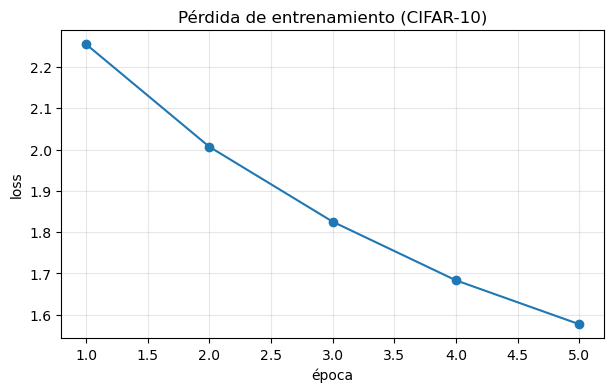

In [10]:
# Curva de pérdida por época
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS + 1), loss_history, marker='o')
plt.title('Pérdida de entrenamiento (CIFAR-10)')
plt.xlabel('época'); plt.ylabel('loss')
plt.grid(alpha=0.3)
plt.show()

Vemos algunas predicciones del conjunto de test para ver cómo está aprendiendo a generalizar. Primero, tomamos una pequeña muestra de imágenes del mismo

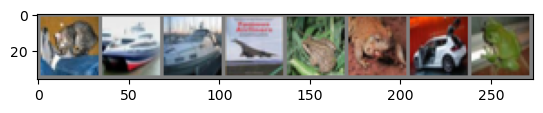

Clases verdaderas:       gato      barco      barco      avión       rana       rana  automóvil       rana


In [11]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# Mostramos las primeras 8 imágenes de prueba y sus clases reales
imshow(torchvision.utils.make_grid(images[:8]))
print('Clases verdaderas:', ' '.join(f'{classes[labels[j]]:>10}' for j in range(8)))

Veamos cuál es la "energía" que nuestro clasificador le asigna a cada una de las imágenes de nuestra muestra. A mayor energía, más la red "piensa" que la imagen pertenece a una clase determinada.

In [12]:
net.eval()
with torch.no_grad():
    outputs = net(images.to(device))
    print(outputs[:4])   # logits ("energía") de las primeras 4 imágenes

tensor([[-0.9681, -0.4652,  0.3635,  1.7405, -0.7702,  1.1551,  1.1442, -1.5306,
         -0.6361, -0.4763],
        [ 3.7843,  4.1307, -0.6623, -2.8996, -1.5897, -4.0679, -4.1002, -3.6582,
          5.4872,  2.7000],
        [ 1.6959,  3.0867, -0.5993, -1.2600, -1.8698, -2.0135, -2.6417, -2.1841,
          2.7253,  2.5035],
        [ 3.6036,  1.8061,  0.0108, -2.3292, -0.2774, -2.9607, -2.8829, -2.2346,
          3.9099,  0.5304]])


Veamos los índices para las mayores energías de cada clase...

In [13]:
# El índice de la mayor "energía" (logit) es la clase predicha
_, predicted = torch.max(outputs, 1)
print('Clases estimadas:', ' '.join(f'{classes[predicted[j]]:>10}' for j in range(8)))

Clases estimadas:       gato      barco  automóvil      barco     pájaro       rana  automóvil       rana


Veamos cómo rindió nuestra red para todo el conjunto de test

In [14]:
correct = 0
total = 0
net.eval()
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Precisión de la red sobre las 10 000 imágenes de prueba: {100 * correct / total:.1f} %')

Precisión de la red sobre las 10 000 imágenes de prueba: 44.7 %


Teniendo en cuenta que un clasificador **aleatorio** acertaría solo el ~10 % (hay 10 clases), el resultado es un buen punto de partida para una red tan pequeña. Como referencia, un humano acierta ~94 % en CIFAR-10.

Veamos ahora la precisión **por clase**, que revela qué categorías le cuestan más a la red:


In [15]:
class_correct = [0.0] * 10
class_total = [0.0] * 10
net.eval()
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        aciertos = (predicted == labels)
        for i in range(labels.size(0)):
            label = labels[i]
            class_correct[label] += aciertos[i].item()
            class_total[label] += 1

for i in range(10):
    print(f'Precisión para la clase {classes[i]:>10} : {100 * class_correct[i] / class_total[i]:.0f} %')

Precisión para la clase      avión : 50 %
Precisión para la clase  automóvil : 71 %
Precisión para la clase     pájaro : 25 %
Precisión para la clase       gato : 35 %
Precisión para la clase     ciervo : 28 %
Precisión para la clase      perro : 51 %
Precisión para la clase       rana : 52 %
Precisión para la clase    caballo : 40 %
Precisión para la clase      barco : 56 %
Precisión para la clase     camión : 39 %


> **¿Cómo mejorarías el desempeño de la red?** Algunas ideas: añadir más capas convolucionales, usar `BatchNorm` y `Dropout`, aplicar *data augmentation*, cambiar el optimizador a `Adam`, o entrenar más épocas. ¡Inténtalo!


## Transfer Learning con CNN

Hasta aquí entrenamos una CNN pequeña, desde cero, sobre un dataset de imágenes también pequeñas. Sin embargo, en el mundo real existen datasets **enormes**. Por ejemplo, [ImageNet](https://www.image-net.org/):

- Contiene más de **14 millones** de imágenes anotadas a mano (~150 GB) con una resolución promedio de $469\times387$ píxeles.
- Cada imagen pertenece a una de miles de categorías organizadas jerárquicamente según la taxonomía de WordNet (por ejemplo, *invertebrado → artrópodo → arácnido*).


Entrenar una red grande sobre un dataset de esa magnitud requiere muchísimos recursos. Por eso, en la práctica **rara vez se entrena una CNN desde cero**; en su lugar se hace ***transfer learning***: se toma una arquitectura con sus **pesos ya preentrenados** (normalmente sobre ImageNet) y se **adapta** a nuestro problema.

PyTorch ofrece [modelos preentrenados](https://pytorch.org/vision/stable/models.html) listos para usar. Estos modelos esperan imágenes normalizadas con las medias y desviaciones de ImageNet: `mean = [0.485, 0.456, 0.406]` y `std = [0.229, 0.224, 0.225]` (y suelen redimensionarse a un tamaño homogéneo, típicamente $224\times224$).


Veremos **dos estrategias** de transfer learning, ambas partiendo de una red preentrenada en ImageNet (un dominio parecido al nuestro) y descartando su última capa (la asociada a las 1000 clases de ImageNet):

1. **Extracción de características** (*feature extraction*): se **congelan** todos los pesos de la red preentrenada y se usa como un extractor fijo de características. Esas características alimentan luego a un modelo tradicional (KNN, SVM, etc.).
2. **Ajuste fino** (*fine-tuning*): se descongelan una o varias capas finales de la red y se **reanuda su optimización** para adaptarlas a nuestro problema.

Nuestro problema de ejemplo: clasificar imágenes de **abejas** y **hormigas** (2 clases).


Usaremos el dataset *hymenoptera* (abejas y hormigas). La siguiente celda lo **descarga y descomprime automáticamente** en `./data/hymenoptera_data`. Si la descarga automática falla, puedes bajarlo manualmente desde [este enlace](https://download.pytorch.org/tutorial/hymenoptera_data.zip) y extraerlo en esa carpeta.

#### Alternativa 1: uso de redes pre-entrenadas como extractores de features

In [16]:
# descargamos y extraemos los archivos (fuente: https://discuss.pytorch.org/t/how-does-one-download-a-data-set-from-a-file-automatically-with-pytorch/74262)
# (requiere ipywidgets, que se instala mediante conda install -c conda-forge ipywidgets o pip3 install ipywidgets --user sin conda)

from torchvision.datasets.utils import download_and_extract_archive
import os

if not os.path.exists("./data/hymenoptera_data"):

    url = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
    root = './data/'

    download_and_extract_archive(url, root)
    print("Archivos descargados y extraidos con éxito")
    
else:
    print("La carpeta ya existe")

100%|██████████| 47.3M/47.3M [00:03<00:00, 12.1MB/s]


Archivos descargados y extraidos con éxito


Definimos importaciones, variables iniciales y transformaciones que aplicaremos a cada imagen

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import os

from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid
from torchvision import transforms
from torch.utils.data import DataLoader
from utils import imshow_tensor

path = './data/hymenoptera_data/'

batch_size = 4
num_workers = 2

# transformaciones que se aplicarán sobre cada imagen:
#   1. el lado más chico de la imagen a 256 pixels manteniendo relación de aspecto (PIL -> PIL)
#   2. crop de la región central de 224x224 pixels (PIL -> PIL)
#   1. transformar la imagen PIL a un tensor de pytorch (PIL -> Tensor)
#   2. aplicar la normalización (estandarización) con la que fueron entrenados los modelos en torchvision  (Tensor -> Tensor)
transform = transforms.Compose([    
    transforms.Resize(256),    
    transforms.CenterCrop(224),   
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [18]:
transform

Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Definimos el dataset y visualizamos algunas imágenes

torch.Size([4, 3, 224, 224])
tensor([0, 0, 0, 1])
['ants', 'ants', 'ants', 'bees']


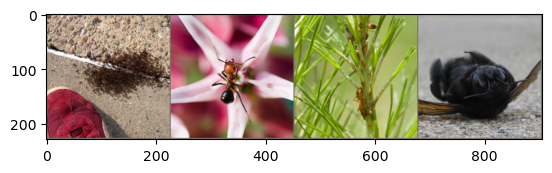

In [19]:
# dataset
data = ImageFolder(os.path.join(path, 'train'), transform)

# data loader
loader = DataLoader(data, batch_size=batch_size, shuffle=True, num_workers=num_workers)

image_batch, labels = next(iter(loader))
print(image_batch.size())
print(labels)
print([data.classes[lbl] for lbl in labels])
grid = make_grid(image_batch)
imshow_tensor(grid)
  

Para utilizar una red pre-entrenada para la extracción de features, debemos limitarla a lo que nos interesa. En nuestro caso emplearemos la red ResNet, donde utilizaremos la salida de la penúltima capa como representación de la imagen.

In [20]:
import torch
from torch import nn
from torchvision import models
from torchvision.models import ResNet18_Weights
from tqdm.notebook import tqdm as progressbar   # API moderna de tqdm para notebooks


class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        # Red preentrenada en ImageNet (API moderna con 'weights')
        model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

        # Congelamos todos los parámetros (no se entrenarán)
        for p in model.parameters():
            p.requires_grad_(False)

        # Modelo secuencial con todas las capas EXCEPTO la última (fc)
        layers = list(model.children())[:-1]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        N = x.size(0)                # tamaño del batch
        x = self.net(x)
        return x.view(N, -1)         # aplanamos la salida a un vector por imagen

Creamos nuestra función de extracción de features. La misma toma como entrada el nombre del subconjunto (train o val), carga y transforma el dataset, y devuelve los features X extraídos con el método anterior y sus respectivas etiquetas.

In [21]:
def features_and_labels(set_):
    if set_ not in ('train', 'val'):
        raise ValueError('not a valid data set')
        
    transform = transforms.Compose([    
        transforms.Resize(256),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    data = ImageFolder(os.path.join(path, set_), transform)
    
    loader = DataLoader(data, batch_size=1, shuffle=False, num_workers=0)
    
    extractor = FeatureExtractor()
    # extractor = extractor.to(device)
    extractor.eval()
    
    features, labels = [], []
    
    for img, lbl in progressbar(loader):
        # img = img.to(device)
        feat = extractor(img)    
        # feat = feat.cpu()
        features.append(feat)
        labels.append(lbl)

    features = torch.cat(features, dim=0)
    labels = torch.cat(labels, dim=0)
    
    return features, labels


Extraemos los features de la salida

In [22]:
train_features, train_labels = features_and_labels('train')
val_features, val_labels = features_and_labels('val')
print(train_features.size(), val_features.size())

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\x/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:03<00:00, 11.9MB/s]


  0%|          | 0/244 [00:00<?, ?it/s]

  0%|          | 0/153 [00:00<?, ?it/s]

torch.Size([244, 512]) torch.Size([153, 512])


Ahora usamos las características extraídas por ResNet como **entrada de un clasificador clásico** de scikit-learn (SVM y KNN). Observa lo potente que resulta: sin entrenar ninguna red, obtenemos buena precisión gracias a las representaciones aprendidas por el modelo preentrenado.

In [23]:
x_train, y_train = train_features.cpu().numpy(), train_labels.cpu().numpy().ravel()
x_test, y_test = val_features.cpu().numpy(), val_labels.cpu().numpy().ravel()

print("Features de entrenamiento:", x_train.shape, "| de prueba:", x_test.shape)

# Entrenamos un clasificador clásico de sklearn sobre las características extraídas por ResNet
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

svm = SVC(kernel='linear', C=1.0).fit(x_train, y_train)
knn = KNeighborsClassifier(n_neighbors=5).fit(x_train, y_train)

print(f"Precisión SVM (lineal) en validación: {svm.score(x_test, y_test):.3f}")
print(f"Precisión KNN (k=5)   en validación: {knn.score(x_test, y_test):.3f}")

Features de entrenamiento: (244, 512) | de prueba: (153, 512)
Precisión SVM (lineal) en validación: 0.967


c:\Users\x\.conda\envs\aaa_curso_2026\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Precisión KNN (k=5)   en validación: 0.954


### Alternativa 2: Ajuste fino (*fine-tuning*)

Aquí adaptamos un modelo preentrenado en ImageNet. La idea: tomamos el modelo preentrenado y **reemplazamos su última capa** (la que define el número de salidas, p. ej. las 1000 clases de ImageNet) por una nueva capa adaptada a nuestras 2 clases.

- Si tenemos **pocos** datos de entrenamiento, adaptamos solo esa última capa (congelando el resto).
- Si tenemos **más** datos, podemos descongelar y adaptar más capas (en general, desde la salida hacia la entrada).

En PyTorch, controlamos qué parámetros se entrenan mediante el atributo `requires_grad` de cada tensor: **solo** los que tengan `requires_grad=True` se actualizarán durante la optimización.


In [24]:
# Cargamos el modelo preentrenado (API moderna con 'weights')
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

# Congelamos todos los parámetros
for p in model.parameters():
    p.requires_grad_(False)

# Reemplazamos la última capa lineal (model.fc en ResNet) por una nueva para 2 clases.
# La nueva capa se crea con requires_grad=True por defecto, así que SÍ se entrenará.
in_features = model.fc.in_features
num_classes = 2
model.fc = nn.Linear(in_features, num_classes)

# Lista de parámetros a optimizar (solo los de la nueva capa fc)
parameters_to_update = [p for p in model.parameters() if p.requires_grad]

Con el modelo definido, resta armar el resto de la estructura de entrenamiento (data loaders, funciones de costo y optimización)

In [25]:
batch_size = 32
num_workers = 0   # en Windows/Jupyter conviene 0 para evitar problemas de multiproceso

# Transformaciones: aumento de datos en 'train' y solo redimensionado/recorte en 'val'
data_transform = {
    'train': transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),          # data augmentation
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
    'val': transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
}

In [26]:
# Datasets de entrenamiento y validación
data = {
    'train': ImageFolder(os.path.join(path, 'train'), data_transform['train']),
    'val':   ImageFolder(os.path.join(path, 'val'),   data_transform['val']),
}

# DataLoaders
data_loader = {
    'train': DataLoader(data['train'], batch_size=batch_size, shuffle=True,  num_workers=num_workers),
    'val':   DataLoader(data['val'],   batch_size=batch_size, shuffle=False, num_workers=num_workers),
}

criterion = nn.CrossEntropyLoss()

# Solo optimizamos los parámetros descongelados (la nueva capa fc). lr=0.001 es un valor razonable
optimizer = torch.optim.Adam(parameters_to_update, lr=0.001)

Definimos funciones de entrenamiento y validación de nuestro modelo

In [27]:
def train(model, data_loader, criterion, optimizer, device):
    model.train()
    running_loss, running_correct = 0.0, 0

    for inputs, labels in data_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_correct += (preds == labels).sum().item()

    n = len(data_loader.dataset)
    return running_loss / n, running_correct / n

In [28]:
def validate(model, data_loader, criterion, device):
    model.eval()
    running_loss, running_correct = 0.0, 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_correct += (preds == labels).sum().item()

    n = len(data_loader.dataset)
    return running_loss / n, running_correct / n

Realizamos el entrenamiento

In [29]:
from tqdm.notebook import tqdm as progressbar   # API moderna de tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

num_epochs = 10

for epoch in progressbar(range(1, num_epochs + 1)):
    train_loss, train_acc = train(model, data_loader['train'], criterion, optimizer, device)
    val_loss, val_acc = validate(model, data_loader['val'], criterion, device)
    print(f'[{epoch}] loss: train={train_loss:.3f}, val={val_loss:.3f} '
          f'-- accuracy: train={train_acc:.3f}, val={val_acc:.3f}')

  0%|          | 0/10 [00:00<?, ?it/s]

[1] loss: train=0.698, val=0.610 -- accuracy: train=0.594, val=0.673
[2] loss: train=0.496, val=0.431 -- accuracy: train=0.795, val=0.902
[3] loss: train=0.404, val=0.359 -- accuracy: train=0.861, val=0.902
[4] loss: train=0.331, val=0.318 -- accuracy: train=0.898, val=0.922
[5] loss: train=0.268, val=0.282 -- accuracy: train=0.955, val=0.922
[6] loss: train=0.228, val=0.255 -- accuracy: train=0.943, val=0.922
[7] loss: train=0.244, val=0.240 -- accuracy: train=0.930, val=0.941
[8] loss: train=0.217, val=0.235 -- accuracy: train=0.914, val=0.928
[9] loss: train=0.175, val=0.219 -- accuracy: train=0.959, val=0.928
[10] loss: train=0.180, val=0.220 -- accuracy: train=0.947, val=0.928


| Concepto en CNN | Por qué importa |
|---|---|
| **Pesos compartidos** | Muchos menos parámetros que un MLP; detecta patrones sin importar su posición |
| **Pooling** | Reduce dimensionalidad y aporta invarianza a traslaciones |
| **Transfer learning** | Aprovecha modelos preentrenados: gran desempeño con pocos datos y poco cómputo |
| **Congelar vs. fine-tuning** | Congela capas si tienes pocos datos; descongela más si tienes muchos |

> Las CNN son la base de la **visión por computadora** moderna. El siguiente paso natural es explorar arquitecturas más avanzadas (ResNet, EfficientNet, Vision Transformers) y técnicas de regularización más sofisticadas.
